# 02 · Baselines: majority class and TF-IDF + linear models

We need a baseline that later neural models must beat. A TF-IDF + logistic regression model is the standard strong baseline for small-data text classification: it is fast, interpretable and hard to beat with little data.

Hyperparameters are chosen on **validation** macro-F1. Test scores are reported for completeness, but no choices are made using them.

**Experiments in this notebook:**
1. Majority class, which gives the floor
2. Word TF-IDF + LogReg, the main baseline
3. Preprocessing ablation: raw vs cleaned text
4. Word vs character n-grams, to test the morphology / OOV hypothesis from notebook 01
5. Class weighting, as a response to the imbalance
6. Other linear classifiers: Linear SVM and Multinomial Naive Bayes

In [1]:
# --- Setup: works both locally and in Google Colab ---
import os, sys
REPO_URL = "https://github.com/Joellate/kiswahili-sentiment-analysis.git"

if "google.colab" in sys.modules:
    if not os.path.exists("kiswahili-sentiment-analysis"):
        !git clone -q $REPO_URL
    %cd kiswahili-sentiment-analysis
    %pip install -q -r requirements.txt
else:
    # running locally from notebooks/
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir("..")

sys.path.insert(0, "src")
print("Working directory:", os.getcwd())

Working directory: C:\Users\AltTronic\kiswahili-sentiment-analysis


In [2]:
import joblib
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

from data import load_all, LABELS
from evaluate import compute_metrics, log_experiment, plot_confusion, report
from preprocessing import clean_series

splits = load_all()
y = {s: d.label.values for s, d in splits.items()}
raw = {s: d.text.tolist() for s, d in splits.items()}
clean = {s: clean_series(d.text) for s, d in splits.items()}
SEED = 42

In [3]:
def run(name, pipeline, texts, config, log=True):
    """Fit on train, score on validation and test, log both, return validation macro-F1."""
    pipeline.fit(texts["train"], y["train"])
    out = {}
    for split in ["validation", "test"]:
        m = compute_metrics(y[split], pipeline.predict(texts[split]))
        if log:
            log_experiment(name, split, m, config)
        out[split] = m
    print(f"{name:45s} val macro-F1 {out['validation']['macro_f1']:.3f} | test macro-F1 {out['test']['macro_f1']:.3f} | test acc {out['test']['accuracy']:.3f}")
    return out

## 1. Majority class: the floor

In [4]:
_ = run("B0 majority class", DummyClassifier(strategy="most_frequent"), raw, {"strategy": "most_frequent"})

B0 majority class                             val macro-F1 0.248 | test macro-F1 0.248 | test acc 0.594


As expected, accuracy is about 59% but macro-F1 is only about 0.25: the model predicts *neutral* for every tweet. Any useful model must clearly beat this macro-F1.

## 2. Tuning the main baseline: word TF-IDF + logistic regression

We tune the regularisation strength `C` and the n-gram range on validation.

In [5]:
rows = []
for ngram in [(1, 1), (1, 2)]:
    for C in [0.3, 1, 3, 10, 30]:
        pipe = Pipeline([("tfidf", TfidfVectorizer(ngram_range=ngram, min_df=1, sublinear_tf=True)),
                         ("clf", LogisticRegression(C=C, max_iter=2000, class_weight="balanced", random_state=SEED))])
        pipe.fit(clean["train"], y["train"])
        rows.append({"ngram": ngram, "C": C, "val_macro_f1": compute_metrics(y["validation"], pipe.predict(clean["validation"]))["macro_f1"]})
grid = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)
grid

,ngram,C,val_macro_f1
8,"(1, 2)",10.0,0.4380
1,"(1, 1)",1.0,0.4379
7,"(1, 2)",3.0,0.4370
9,"(1, 2)",30.0,0.4340
6,"(1, 2)",1.0,0.4309
3,"(1, 1)",10.0,0.4227
0,"(1, 1)",0.3,0.4167
2,"(1, 1)",3.0,0.4125
4,"(1, 1)",30.0,0.4120
5,"(1, 2)",0.3,0.4113


In [6]:
best_word = grid.iloc[0]
WORD_NGRAM, WORD_C = tuple(best_word.ngram), float(best_word.C)
print("Selected:", WORD_NGRAM, "C =", WORD_C)

def word_lr(class_weight="balanced"):
    return Pipeline([("tfidf", TfidfVectorizer(ngram_range=WORD_NGRAM, sublinear_tf=True)),
                     ("clf", LogisticRegression(C=WORD_C, max_iter=2000, class_weight=class_weight, random_state=SEED))])

cfg = {"features": "word tfidf", "ngram": WORD_NGRAM, "C": WORD_C, "class_weight": "balanced", "preprocessing": "clean"}
res_word = run("B1 word TF-IDF + LogReg", word_lr(), clean, cfg)

Selected: (1, 2) C = 10.0


B1 word TF-IDF + LogReg                       val macro-F1 0.438 | test macro-F1 0.474 | test acc 0.588


## 3. Preprocessing ablation: does cleaning help?

We keep the model fixed and change only the input text.

In [7]:
_ = run("B1a word TF-IDF + LogReg (raw text)", word_lr(), raw, {**cfg, "preprocessing": "raw"})

B1a word TF-IDF + LogReg (raw text)           val macro-F1 0.433 | test macro-F1 0.486 | test acc 0.592


## 4. Word vs character n-grams

Character n-grams inside word boundaries (`char_wb`, lengths 2 to 5) let inflected forms such as *nakupenda*, *alikupenda* and *tunakupenda* share features through the common root *-penda*. They also help with spelling variants. If the OOV hypothesis from notebook 01 is right, they should help.

In [8]:
rows = []
for C in [0.3, 1, 3, 10]:
    pipe = Pipeline([("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), sublinear_tf=True)),
                     ("clf", LogisticRegression(C=C, max_iter=3000, class_weight="balanced", random_state=SEED))])
    pipe.fit(clean["train"], y["train"])
    rows.append({"C": C, "val_macro_f1": compute_metrics(y["validation"], pipe.predict(clean["validation"]))["macro_f1"]})
char_grid = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False); display(char_grid)
CHAR_C = float(char_grid.iloc[0].C)

def char_lr(class_weight="balanced"):
    return Pipeline([("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), sublinear_tf=True)),
                     ("clf", LogisticRegression(C=CHAR_C, max_iter=3000, class_weight=class_weight, random_state=SEED))])

res_char = run("B2 char TF-IDF + LogReg", char_lr(), clean,
               {"features": "char_wb 2-5 tfidf", "C": CHAR_C, "class_weight": "balanced", "preprocessing": "clean"})

,C,val_macro_f1
1,1.0,0.4914
0,0.3,0.4701
2,3.0,0.4594
3,10.0,0.4436


B2 char TF-IDF + LogReg                       val macro-F1 0.491 | test macro-F1 0.456 | test acc 0.535


In [9]:
def word_char_lr():
    feats = FeatureUnion([("word", TfidfVectorizer(ngram_range=WORD_NGRAM, sublinear_tf=True)),
                          ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), sublinear_tf=True))])
    return Pipeline([("tfidf", feats),
                     ("clf", LogisticRegression(C=CHAR_C, max_iter=3000, class_weight="balanced", random_state=SEED))])

res_both = run("B3 word+char TF-IDF + LogReg", word_char_lr(), clean,
               {"features": "word + char_wb 2-5 tfidf", "C": CHAR_C, "class_weight": "balanced", "preprocessing": "clean"})

B3 word+char TF-IDF + LogReg                  val macro-F1 0.449 | test macro-F1 0.478 | test acc 0.575


## 5. Class weighting

`class_weight="balanced"` scales the loss of each class inversely to its frequency, so mistakes on the rare *negative* class cost more. Here we check what happens without it.

In [10]:
_ = run("B1b word TF-IDF + LogReg (no class weight)", word_lr(class_weight=None), clean, {**cfg, "class_weight": None})
_ = run("B2b char TF-IDF + LogReg (no class weight)", char_lr(class_weight=None), clean,
        {"features": "char_wb 2-5 tfidf", "C": CHAR_C, "class_weight": None, "preprocessing": "clean"})

B1b word TF-IDF + LogReg (no class weight)    val macro-F1 0.355 | test macro-F1 0.393 | test acc 0.590


B2b char TF-IDF + LogReg (no class weight)    val macro-F1 0.344 | test macro-F1 0.375 | test acc 0.623


## 6. Other linear classifiers

In [11]:
_ = run("B4 word TF-IDF + Linear SVM",
        Pipeline([("tfidf", TfidfVectorizer(ngram_range=WORD_NGRAM, sublinear_tf=True)),
                  ("clf", LinearSVC(C=0.5, class_weight="balanced", random_state=SEED))]),
        clean, {"features": "word tfidf", "model": "LinearSVC", "C": 0.5, "class_weight": "balanced"})
_ = run("B5 word counts + Multinomial NB",
        Pipeline([("tfidf", TfidfVectorizer(ngram_range=WORD_NGRAM, use_idf=False, norm=None)),
                  ("clf", MultinomialNB(alpha=0.5))]),
        clean, {"features": "word counts", "model": "MultinomialNB", "alpha": 0.5})

B4 word TF-IDF + Linear SVM                   val macro-F1 0.411 | test macro-F1 0.443 | test acc 0.583


B5 word counts + Multinomial NB               val macro-F1 0.416 | test macro-F1 0.435 | test acc 0.600


## Results so far

In [12]:
results = pd.read_csv("results/experiments.csv")
cols = ["experiment", "accuracy", "macro_precision", "macro_recall", "macro_f1", "f1_positive", "f1_neutral", "f1_negative"]
table = (results.pivot_table(index="experiment", columns="split", values="macro_f1")
         .rename(columns=lambda c: f"{c}_macro_f1").sort_values("validation_macro_f1", ascending=False))
display(table)
results.query("split == 'test'")[cols].sort_values("macro_f1", ascending=False).reset_index(drop=True)

split,test_macro_f1,validation_macro_f1
experiment,,
B2 char TF-IDF + LogReg,0.4557,0.4914
B3 word+char TF-IDF + LogReg,0.4776,0.4486
B1 word TF-IDF + LogReg,0.4741,0.4380
B1a word TF-IDF + LogReg (raw text),0.4865,0.4332
B5 word counts + Multinomial NB,0.4346,0.4156
B4 word TF-IDF + Linear SVM,0.4427,0.4109
B1b word TF-IDF + LogReg (no class weight),0.3931,0.3550
B2b char TF-IDF + LogReg (no class weight),0.3752,0.3438
B0 majority class,0.2483,0.2478


,experiment,accuracy,macro_precision,macro_recall,macro_f1,f1_positive,f1_neutral,f1_negative
0,B1a word TF-IDF + LogReg (raw text),0.5922,0.5414,0.4675,0.4865,0.4398,0.6948,0.3248
1,B3 word+char TF-IDF + LogReg,0.5749,0.5028,0.4656,0.4776,0.4489,0.6739,0.3101
2,B1 word TF-IDF + LogReg,0.5882,0.5294,0.4570,0.4741,0.4326,0.6940,0.2957
3,B2 char TF-IDF + LogReg,0.5348,0.4556,0.4568,0.4557,0.4289,0.6344,0.3038
4,B4 word TF-IDF + Linear SVM,0.5829,0.5292,0.4278,0.4427,0.3810,0.6996,0.2476
5,B5 word counts + Multinomial NB,0.6003,0.5539,0.4296,0.4346,0.4439,0.7093,0.1505
6,B1b word TF-IDF + LogReg (no class weight),0.5896,0.5505,0.3978,0.3931,0.3760,0.7115,0.0920
7,B2b char TF-IDF + LogReg (no class weight),0.6230,0.7376,0.3943,0.3752,0.3280,0.7489,0.0488
8,B0 majority class,0.5936,0.1979,0.3333,0.2483,0.0000,0.7450,0.0000


## Selecting and saving the best baseline

We select the baseline by **validation** macro-F1, then refit it on train and save it. The web app can load this model as a lightweight fallback.

Best baseline on validation: B2 char TF-IDF + LogReg


              precision    recall  f1-score   support

    positive      0.409     0.451     0.429       224
     neutral      0.650     0.619     0.634       444
    negative      0.308     0.300     0.304        80

    accuracy                          0.535       748
   macro avg      0.456     0.457     0.456       748
weighted avg      0.541     0.535     0.537       748



['models/baseline_tfidf_lr.joblib']

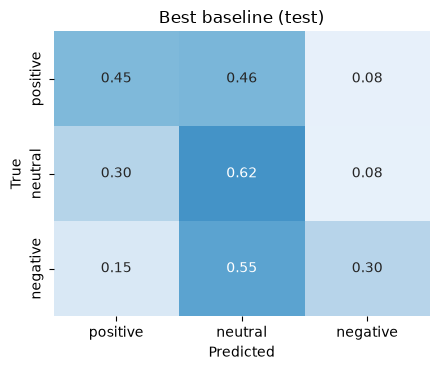

In [13]:
val = results[(results.split == "validation") & results.experiment.str.match(r"B[1-5]")]
best_name = val.sort_values("macro_f1", ascending=False).experiment.iloc[0]
print("Best baseline on validation:", best_name)
builders = {"B1 word TF-IDF + LogReg": word_lr, "B2 char TF-IDF + LogReg": char_lr, "B3 word+char TF-IDF + LogReg": word_char_lr}
best_pipe = builders.get(best_name, word_char_lr)()
best_pipe.fit(clean["train"], y["train"])
test_pred = best_pipe.predict(clean["test"])
print(report(y["test"], test_pred))
_ = plot_confusion(y["test"], test_pred, "Best baseline (test)", save_as="cm_best_baseline.png")
os.makedirs("models", exist_ok=True)
joblib.dump(best_pipe, "models/baseline_tfidf_lr.joblib")

## Quick look at errors

The full error analysis is in notebook 05. Here we only look at the most confident mistakes.

In [14]:
proba = best_pipe.predict_proba(clean["test"])
err = splits["test"].assign(pred=[LABELS[i] for i in test_pred], confidence=proba.max(1))
err = err[err.label != test_pred].sort_values("confidence", ascending=False)
print(f"{len(err)} / {len(splits['test'])} test tweets misclassified")
err[["text", "label_name", "pred", "confidence"]].head(15)

348 / 748 test tweets misclassified


,text,label_name,pred,confidence
563,NUKUU Mfanyabiashara msikubali kutoa rushwa kw...,neutral,positive,0.830106
376,Habari Ahsante kwa kuwasiliana nasi Pole sana ...,neutral,positive,0.773748
109,Ahsante kwa kutembelea ukurasa wetu Tumia Ezyp...,neutral,positive,0.755486
573,Habari Ramadhan Chuma Ahsante kwa kuwasilian n...,neutral,positive,0.722228
428,Habari Ahsante kwa kuwasiliana nasi Tunaomba k...,neutral,positive,0.720799
540,Habari Ahsante kwa kuwasiliana nasi Tunaomba k...,neutral,positive,0.719790
482,Huu ndio ukweli ambao kuna watu hawataki ku...,neutral,negative,0.712640
512,Luteni Jenerali Mohamed alisema jamii ya mchez...,neutral,positive,0.698174
378,Tembelea tawi letu karibu nawe au tupigie kupi...,neutral,positive,0.671480
461,Sisi 4 Mbeya City 0,positive,neutral,0.660079


## Takeaways

1. **The task is hard.** The best linear models reach about 0.45–0.49 macro-F1, roughly double the majority-class floor of 0.25 but still far from solved. Accuracy alone is misleading here: the majority baseline has *higher* accuracy (0.59) than several real models.
2. **Class weighting is the single largest effect.** Without it, negative-class F1 falls to about 0.05–0.09, because the model almost never predicts the rare class. With it, negative-class F1 is about 0.30 and macro-F1 rises by about 0.08–0.11.
3. **Character n-grams won on validation (0.491) but not on test (0.456).** The validation set has only 453 tweets, of which just 48 are negative, so differences of about ±0.03 are within noise. Two lessons follow. First, a single validation score is a shaky basis for model selection on this dataset. Second, later experiments should report **several random seeds**.
4. **Cleaning makes no measurable difference** (B1 vs B1a). This is plausible because the release was already stripped of emojis, punctuation and mentions.
5. **The negative class is the bottleneck** for every model (F1 ≤ 0.33). It has the fewest examples, and its indicative words in notebook 01 (*amefariki*, *polisi*, *jeshi*, *kosa*) are largely *news topics* (deaths, police, army), not expressions of opinion.

These results set the bar for the neural models in notebooks 03 (BiLSTM) and 04 (fine-tuned Transformers). We expect pretrained models to help most, because the bottleneck is lexical coverage (50% type OOV on test), and pretraining supplies exactly that.